<a href="https://colab.research.google.com/github/Raffikusuma/Comvis/blob/main/Raffi2318009ExtraksiFiturWarna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Load data 10 File Citra yang ada pada file Google Drive Anda

In [ ]:
import os

folder = '/content/drive/MyDrive/Comvis/Folder 10 Citra'

STEP 3 — Import Library

In [ ]:
import cv2
import pandas as pd
import numpy as np

STEP 4 — Siapkan Variabel

In [ ]:
data = []

STEP 5 — Loop Baca Gambar

In [ ]:
for file in os.listdir(folder):
    if file.endswith('.jpg') or file.endswith('.png'):
        path = os.path.join(folder, file)

        img = cv2.imread(path)
        img = cv2.resize(img, (256, 256))

STEP 6 — Konversi ke HSV

In [ ]:
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        h, s, v = cv2.split(hsv)

STEP 7 — Hitung Mean HSV

In [ ]:
        mean_h = np.mean(h)
        mean_s = np.mean(s)
        mean_v = np.mean(v)

STEP 8 — Hitung Standar Deviasi

In [ ]:
        std_h = np.std(h)
        std_s = np.std(s)
        std_v = np.std(v)

STEP 9 — Klasifikasi (Segar / Busuk)

In [ ]:
        if mean_v < 100:
            kondisi = "Busuk"
        else:
            kondisi = "Segar"

In [ ]:
print(f"""
Nama File : {file}

Mean HSV  : H={mean_h:.2f}, S={mean_s:.2f}, V={mean_v:.2f}
Std HSV   : H={std_h:.2f}, S={std_s:.2f}, V={std_v:.2f}

Kondisi   : {kondisi}
""")


Nama File : Image_9.jpg

Mean HSV  : H=49.77, S=24.17, V=156.03
Std HSV   : H=54.52, S=40.46, V=47.24

Kondisi   : Segar



STEP 10 — Simpan ke List

In [ ]:
data.append([
            file,
            mean_h, mean_s, mean_v,
            std_h, std_s, std_v,
            kondisi
        ])

STEP 11 — Buat DataFrame

In [ ]:
columns = [
    'Nama File',
    'Mean_H', 'Mean_S', 'Mean_V',
    'Std_H', 'Std_S', 'Std_V',
    'Kondisi'
]

# Tambahkan kolom histogram
for i in range(24):
    columns.append(f'Hist_{i}')

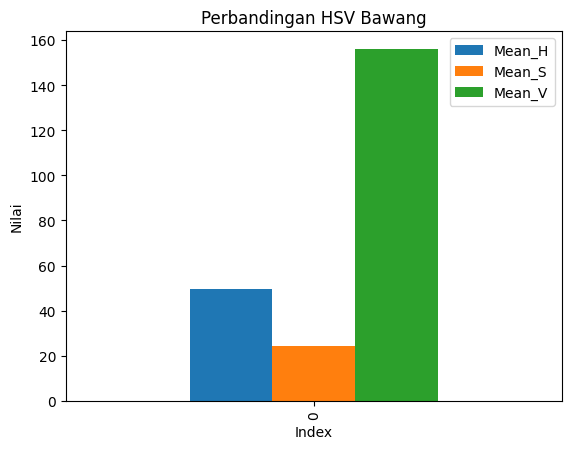

In [ ]:
import matplotlib.pyplot as plt

df[['Mean_H','Mean_S','Mean_V']].plot(kind='bar')
plt.title('Perbandingan HSV Bawang')
plt.xlabel('Index')
plt.ylabel('Nilai')
plt.show()

In [ ]:
df.to_csv('/content/drive/MyDrive/fitur_bawang.csv', index=False)
df.to_excel('/content/drive/MyDrive/fitur_bawang.xlsx', index=False)

print("Berhasil disimpan!")

Berhasil disimpan!
